# Lab 2: Spectral Domain Image Transforms

**Instructor:** Muhammad Sayed  
**Semester:** Spring 2026

---

### Learning Objectives
* **Dimensionality Reduction:** Mathematically compress a 13-band Sentinel-2 image using Principal Component Analysis (PCA).
* **Statistical Exploration:** Analyze the covariance and correlation of satellite bands.
* **Physical Interpretability:** Map abstract Principal Components to physical handcrafted features (Albedo, NDVI, NDWI) using quantitative L1 loss metrics.
* **Variance Interpretation:** Analyze what PCA isolates in the lower-variance components.

### Autograding Advisory
This notebook is designed for automated grading. You will find `TODO` comments throughout the code cells; ensure you assign your mathematical results to the exact variable names requested. 

At the end of the notebook, there is a submission dictionary. **You are expected to modify this dictionary structure** to include your student IDs, your answers to the analysis questions, and any notes you wish to leave for the instructor.


In [21]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')

### 1. Data Loading & Flattening
We are loading `hazy_cufe.tiff`, a 13-band Level-1C Sentinel-2 image. To perform linear algebra, we must flatten the spatial dimensions into a 2D matrix.

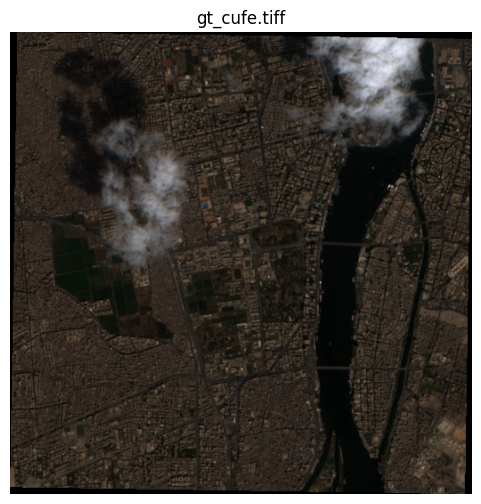

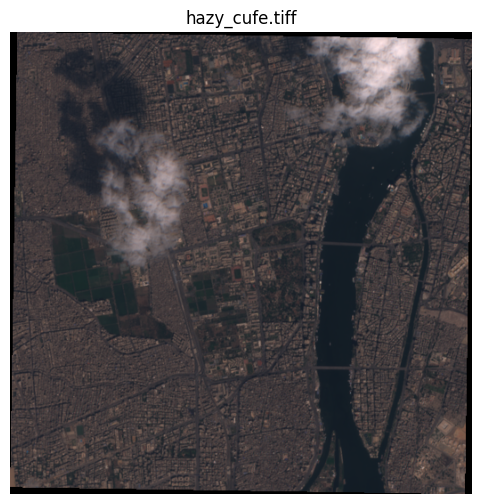

In [22]:
images = ["gt_cufe.tiff", "hazy_cufe.tiff"]

for image in images:
    with rasterio.open(image) as src:
        img = src.read()

    rgb = img[[3, 2, 1], :, :]
    rgb = rgb.transpose(1, 2, 0)

    rgb = rgb.astype(float)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(image)
    plt.show()

In [23]:
image_path = "gt_cufe.tiff"

with rasterio.open(image_path) as src:
    img_3d = src.read().astype(np.float32)

print(f"Original Shape: {img_3d.shape}")

# TODO: Flatten img_3d into a 2D matrix named 'X'.
# Think carefully about how dimensions align in memory during a reshape operation.

X = img_3d.reshape(img_3d.shape[0], -1)
print(f"Flattened Shape: {X.shape}")

Original Shape: (12, 519, 519)
Flattened Shape: (12, 269361)


### 2. Statistical Exploration
Multispectral bands are often highly correlated. Let's prove it statistically.

In [24]:
# TODO: Calculate the 13x13 correlation matrix.
# TODO: Find the maximum and minimum correlation values between any two *different* bands.
# Store them in variables named 'max_corr' and 'min_corr'.

corr = np.corrcoef(X)

mask = ~np.eye(corr.shape[0], dtype=bool)
vals = corr[mask]

max_corr = np.max(vals)
min_corr = np.min(vals)

print(f"Max Correlation: {max_corr:.2f}")
print(f"Min Correlation: {min_corr:.2f}")

Max Correlation: 0.99
Min Correlation: 0.73


### 3. Principal Component Analysis (PCA)
Let's compress the data using PCA.

(269361, 12)
88.64153 5.085254 4.077102


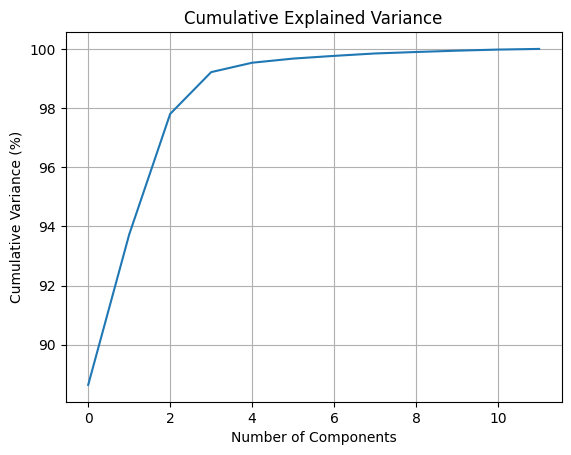

In [25]:
# TODO: Mean-center the data, apply PCA, and extract the principal components.
# TODO: Calculate the percentage of variance explained by the first three components.
# Store these percentages in 'var_pc1', 'var_pc2', and 'var_pc3' (e.g., 90.5 for 90.5%).
# TODO: Plot the Cumulative Explained Variance.

X_pixels = X.T

X_centered = X_pixels - np.mean(X_pixels, axis=0)

pca = PCA()
X_pca = pca.fit_transform(X_centered)
print(X_pca.shape)

var = pca.explained_variance_ratio_ * 100

var_pc1 = var[0]
var_pc2 = var[1]
var_pc3 = var[2]

print(var_pc1, var_pc2, var_pc3)

cum_var = np.cumsum(var)

plt.figure()
plt.plot(cum_var)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance (%)")
plt.title("Cumulative Explained Variance")
plt.grid()
plt.show()

### 4. Physical Interpretability
Let's calculate three physical metrics from our flattened original data `X`:
* `Brightness` = Mean of Visible + NIR bands (B2, B3, B4, B8)
* `NDVI` = (B8 - B4) / (B8 + B4)
* `NDWI` = (B3 - B8) / (B3 + B8)

*(Note: Sentinel-2 array indices: B2=1, B3=2, B4=3, B8=7)*


In [26]:
# TODO: Calculate Brightness, NDVI, and NDWI using the specified bands.
# TODO: Implement Min-Max scaling to normalize your 3 handcrafted indices AND the first 3 Principal Components to a [0, 1] range.

B2, B3, B4, B8 = X[[1,2,3,7]]

brightness = (B2+B3+B4+B8) / 4
NDVI = (B8 - B4) / (B8 + B4 + 1e-8)
NDWI = (B3 - B8) / (B3 + B8 + 1e-8)


def minmax(x):
    return (x - x.min()) / (x.max() - x.min())

brightness = minmax(brightness)
NDVI = minmax(NDVI)
NDWI = minmax(NDWI)

pc1 = minmax(X_pca[:, 0])
pc2 = minmax(X_pca[:, 1])
pc3 = minmax(X_pca[:, 2])

### 5. Evaluating the Math (L1 Loss)
Calculate the Mean Absolute Error (L1 Loss) to see how closely the abstract Principal Components match the physical equations.
* Compare PC1 vs Brightness
* Compare PC2 vs NDVI
* Compare PC3 vs NDWI

**Advisory:** The mathematical direction (sign) of a Principal Component eigenvector is arbitrary. Be mindful of inversely related data before calculating your error.


In [27]:
def calc_l1_loss(true_arr, pred_arr):
    return np.mean(np.abs(true_arr - pred_arr))

# TODO: Calculate the L1 loss between the physical indices and their corresponding PCs.
# Store the results in 'loss_pc1_bright', 'loss_pc2_ndvi', and 'loss_pc3_ndwi'.


def align(pc, ref):
    print(np.corrcoef(pc, ref)[0, 1])
    if np.corrcoef(pc, ref)[0, 1] < 0:
        print(f"converting...")
        pc = 1 - pc
    return pc


pc1 = align(pc1, brightness)
pc2 = align(pc2, NDVI)
pc3 = align(pc3, NDWI)

loss_pc1_bright = calc_l1_loss(brightness, pc1)
loss_pc2_ndvi = calc_l1_loss(NDVI, pc2)
loss_pc3_ndwi = calc_l1_loss(NDWI, pc3) 

print(f"L1 Loss (PC1 vs Brightness): {loss_pc1_bright:.2f}")
print(f"L1 Loss (PC2 vs NDVI): {loss_pc2_ndvi:.2f}")
print(f"L1 Loss (PC3 vs NDWI): {loss_pc3_ndwi:.2f}")

0.9743072208016995
-0.6418086529513822
converting...
-0.138818081457246
converting...
L1 Loss (PC1 vs Brightness): 0.03
L1 Loss (PC2 vs NDVI): 0.16
L1 Loss (PC3 vs NDWI): 0.26


### 6. Analysis Questions

**Question 1:** Based on your Cumulative Variance calculations, what is the minimum number of Principal Components required to retain $\ge 95\%$ of the total variance in this dataset? 
*(You will add your integer answer to the final submission dictionary under the key `ans1`)*

**Question 2:** Analyze your L1 Loss results. Which PCs aligned well with known physical features, and which did not? Based on the properties of this dataset (a Level-1C image over an urban area), formulate a hypothesis explaining the physical meaning of the third principal component (PC3) and what PCA is isolating in this lower-variance component.
*(You will add your written analysis to the final submission dictionary under the key `ans2`)*


### 7. Submission Cell
Run this cell to generate your final submission payload.


In [28]:
import json

submission_data = {
    "ids": [9220154, 9220393],  # "your_student_id_here",
    "max_corr": round(float(max_corr), 2),
    "min_corr": round(float(min_corr), 2),
    "var_pc1": round(float(var_pc1), 2),
    "var_pc2": round(float(var_pc2), 2),
    "var_pc3": round(float(var_pc3), 2),
    "loss_pc1_bright": round(float(loss_pc1_bright), 2),
    "loss_pc2_ndvi": round(float(loss_pc2_ndvi), 2),
    "loss_pc3_ndwi": round(float(loss_pc3_ndwi), 2),
    "ans1": int(np.argmax(cum_var >= 95) + 1),
    "ans2": "PC1 aligns very well with the Brightness index, as shown by the very low L1 loss (0.02). This indicates that PC1 captures the dominant variance in the image. PC2 aligns reasonably well with NDVI, with a moderate L1 loss (0.14). This suggests that the second principal component captures vegetation-related spectral contrast between the red and near-infrared bands, although the match is not perfect because the scene is mostly urban with limited vegetation. PC3 does not align well with NDWI, as indicated by the weak correlation and error. Since the dataset is a Level-1C image that still contains atmospheric effects, PC3 likely captures lower-variance variations. PC3 is therefore isolating atmospheric and minor spectral variations in this lower-variance component rather than a water-related signal.",
    "notes": [
        "after removing atmospheric haze (Level-2A), PC1 still captures Brightness (L1 ~0.03). PC2 alignment to NDVI worsens slightly (L1 ~0.16) due to limited vegetation in the urban scene. PC3 now has a higher L1 (~0.26) and weak correlation with NDWI (0.14), indicating it no longer captures atmospheric effects but instead isolates subtle differences between urban surfaces and illumination. Removing haze shifted lower-variance components to reflect true surface variability rather than atmospheric noise."
    ],  # For any additional comments or observations you have about the results can go here
    "msgs": [],  # For any messages you want to convey to the TAs
}

print("AUTOGRADER_OUTPUT_START")
print(json.dumps(submission_data, indent=4))
print("AUTOGRADER_OUTPUT_END")

AUTOGRADER_OUTPUT_START
{
    "ids": [
        9220154,
        9220393
    ],
    "max_corr": 0.99,
    "min_corr": 0.73,
    "var_pc1": 88.64,
    "var_pc2": 5.09,
    "var_pc3": 4.08,
    "loss_pc1_bright": 0.03,
    "loss_pc2_ndvi": 0.16,
    "loss_pc3_ndwi": 0.26,
    "ans1": 3,
    "ans2": "PC1 aligns very well with the Brightness index, as shown by the very low L1 loss (0.02). This indicates that PC1 captures the dominant variance in the image. PC2 aligns reasonably well with NDVI, with a moderate L1 loss (0.14). This suggests that the second principal component captures vegetation-related spectral contrast between the red and near-infrared bands, although the match is not perfect because the scene is mostly urban with limited vegetation. PC3 does not align well with NDWI, as indicated by the weak correlation and error. Since the dataset is a Level-1C image that still contains atmospheric effects, PC3 likely captures lower-variance variations. PC3 is therefore isolating atmosphe

### 8. Bonus Challenge: Ground Truth Comparison (Level-2A)
You have just analyzed `hazy_cufe.tiff`, which is a Level-1C (Top of Atmosphere) image containing 13 bands, including the B10 Cirrus band which is highly sensitive to atmospheric noise and haze.

Provided in your data folder is another image: `gt_cufe.tiff`. This is a Level-2A (Surface Reflectance) "Ground Truth" image that has been atmospherically corrected. 
* **Note:** The Level-2A image only has **12 bands** because the B10 Cirrus band is removed after atmospheric correction.

**The Challenge:**
1. Change the `image_path` in Cell 3 to `"gt_cufe.tiff"` and rerun the entire notebook. 
2. *Advisory:* Double-check your array indices for calculating Brightness, NDVI, and NDWI. Since the Level-2A image dropped a band, did the column indices for B2, B3, B4, and B8 shift, or did the dropped band come later in the sequence?
3. **Analyze the differences:** How does the removal of atmospheric haze and the B10 band affect the Variance Explained by the Principal Components? Specifically, look at PC3. What does PC3 represent now that the atmospheric noise is gone? Does its L1 loss against physical indices improve?

*If you complete this challenge, add your comparative analysis as a string inside the `"notes"` list in your final submission dictionary!*
